# Notebook 04: Seasonal Patterns — The US Grid's Rhythm

**One Sensor, One Year — Edition 2: US Grid**

India's grid breathes with the monsoon. Texas breathes with temperature and wind. The lower-48 — aggregated across every climate zone from the Pacific Northwest to the Gulf Coast to the Northeast — breathes with **two competing peaks**: summer air-conditioning and winter heating.

- Monthly stacked mix (GWh/day and % share)
- Four meteorological seasons side-by-side
- Summer AC surge — does gas or renewables carry the peak?
- Winter heating stress — cold-snap ramps
- Solar's diurnal shape, month by month (the hourly data earns its keep here)
- Monthly emissions intensity

**Inputs:**
- `../data/processed/us48_2025_derived.csv` (from N03 — has emissions columns)
- `../data/processed/us48_2025_hourly.csv` (from N01 — 8760 hours)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')

daily = pd.read_csv(PROCESSED / 'us48_2025_derived.csv', parse_dates=['date'], index_col='date')
hourly = pd.read_csv(PROCESSED / 'us48_2025_hourly.csv', parse_dates=['period'], index_col='period')

print(f'Daily:  {len(daily)} rows × {len(daily.columns)} cols')
print(f'Hourly: {len(hourly)} rows × {len(hourly.columns)} cols')

daily['month'] = daily.index.month
hourly['month'] = hourly.index.month
hourly['hour'] = hourly.index.hour

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

FUEL_COLORS = {
    'COL': '#D4890E', 'NG': '#F0C078', 'NUC': '#2A9D8F', 'WND': '#72B352',
    'SUN': '#F4C430', 'WAT': '#264653', 'OTH': '#9B72CF', 'OIL': '#5A3825',
    'GEO': '#A0524D',
}
FUEL_LABELS = {
    'COL': 'Coal', 'NG': 'Natural Gas', 'NUC': 'Nuclear', 'WND': 'Wind',
    'SUN': 'Solar', 'WAT': 'Hydro', 'OTH': 'Other', 'OIL': 'Oil', 'GEO': 'Geothermal',
}

STORAGE_COLS = [c for c in ['BAT', 'PS', 'OES', 'UES'] if c in daily.columns]
# Keep only fuels present as raw MWh/day columns (derived file has co2_* columns too)
STACK_ORDER = [c for c in ['COL', 'NG', 'NUC', 'WAT', 'WND', 'SUN', 'GEO', 'OTH', 'OIL']
               if c in daily.columns]
print(f'Stack order: {STACK_ORDER}')

Daily:  365 rows × 30 cols
Hourly: 8760 rows × 16 cols
Stack order: ['COL', 'NG', 'NUC', 'WAT', 'WND', 'SUN', 'GEO', 'OTH', 'OIL']


## 1. Monthly stacked mix — GWh/day

Average daily generation per month, stacked by fuel. First visual read of how the mix shifts across the year.

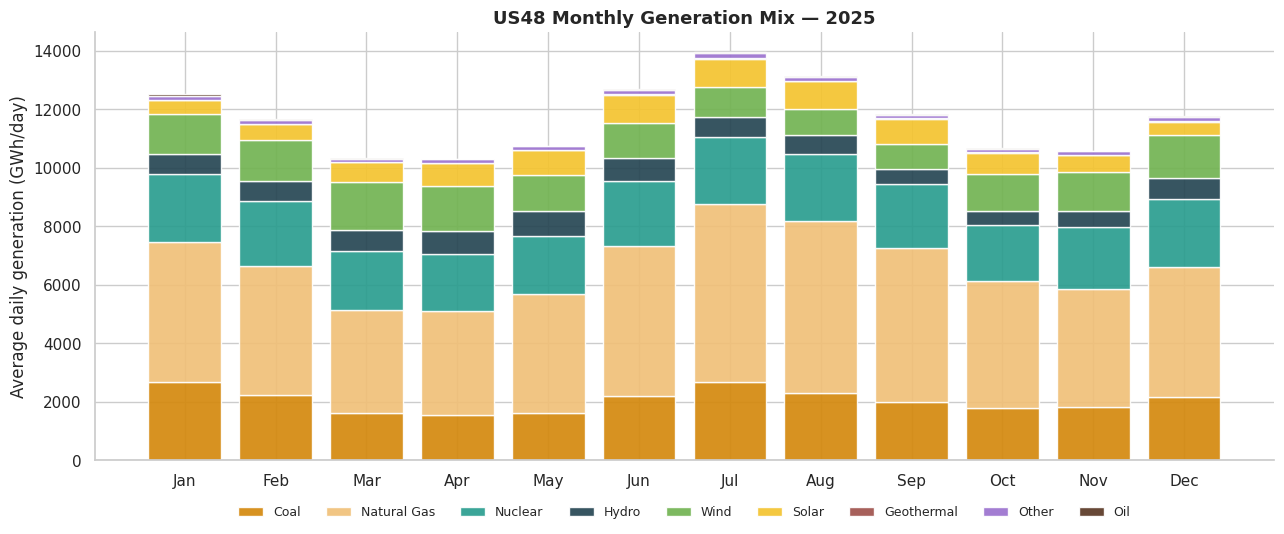

In [2]:
monthly = daily.groupby('month')[STACK_ORDER].mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(12)
for col in STACK_ORDER:
    vals = monthly[col].values / 1e3  # MWh/day → GWh/day
    ax.bar(MONTH_NAMES, vals, bottom=bottom,
           color=FUEL_COLORS.get(col, '#888'),
           label=FUEL_LABELS.get(col, col),
           alpha=0.92, width=0.8)
    bottom += vals

ax.set_ylabel('Average daily generation (GWh/day)')
ax.set_title('US48 Monthly Generation Mix — 2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=9, frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 2. Monthly share — normalized to 100%

Same data, every month rescaled to 100%. Lets us read share shifts independent of absolute generation.

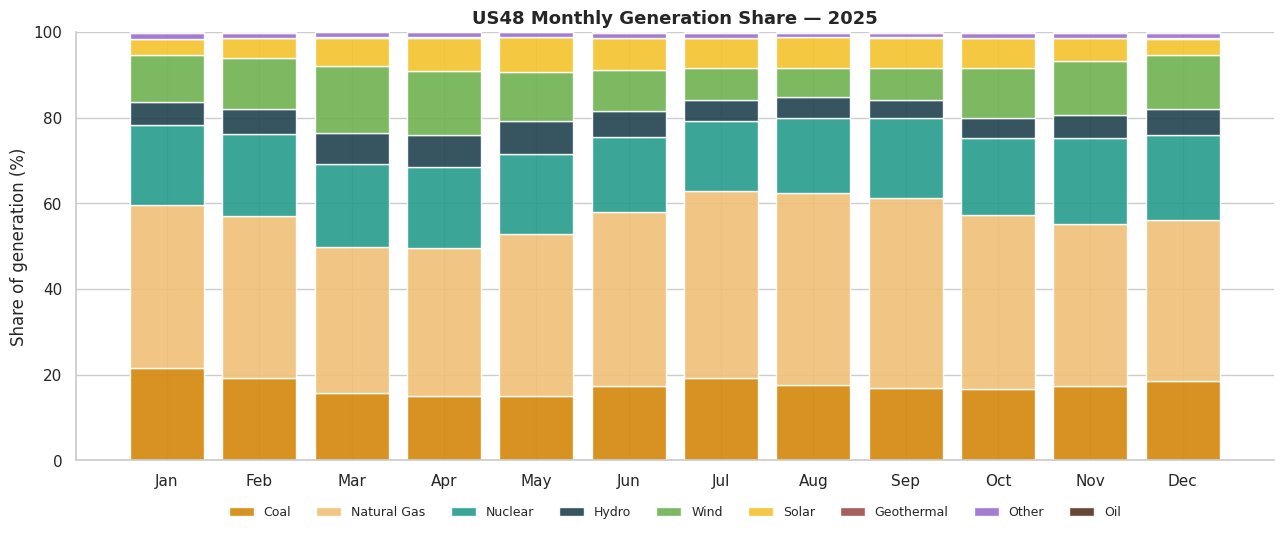

Gas and wind share by month (%):
  Jan: gas  38.1%   wind  11.0%   solar   3.7%
  Feb: gas  37.9%   wind  12.0%   solar   4.6%
  Mar: gas  34.0%   wind  15.7%   solar   6.6%
  Apr: gas  34.4%   wind  14.9%   solar   7.8%
  May: gas  37.8%   wind  11.5%   solar   8.1%
  Jun: gas  40.6%   wind   9.5%   solar   7.5%
  Jul: gas  43.6%   wind   7.4%   solar   6.9%
  Aug: gas  44.8%   wind   6.8%   solar   7.0%
  Sep: gas  44.4%   wind   7.3%   solar   7.2%
  Oct: gas  40.6%   wind  11.8%   solar   6.8%
  Nov: gas  37.9%   wind  12.7%   solar   5.2%
  Dec: gas  37.6%   wind  12.6%   solar   3.8%


In [3]:
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(12)
for col in STACK_ORDER:
    vals = monthly_pct[col].values
    ax.bar(MONTH_NAMES, vals, bottom=bottom,
           color=FUEL_COLORS.get(col, '#888'),
           label=FUEL_LABELS.get(col, col),
           alpha=0.92, width=0.8)
    bottom += vals

ax.set_ylabel('Share of generation (%)')
ax.set_title('US48 Monthly Generation Share — 2025', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=9, frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print('Gas and wind share by month (%):')
for i, m in enumerate(MONTH_NAMES):
    print(f'  {m}: gas {monthly_pct["NG"].iloc[i]:5.1f}%   wind {monthly_pct["WND"].iloc[i]:5.1f}%   solar {monthly_pct["SUN"].iloc[i]:5.1f}%')

## 3. The four seasonal regimes

Meteorological seasons (Dec-Jan-Feb = winter). The US has two demand peaks — summer AC and winter heating — and one renewable peak (spring wind).

In [4]:
SEASONS = {
    'Winter (Dec-Feb)': [12, 1, 2],
    'Spring (Mar-May)': [3, 4, 5],
    'Summer (Jun-Aug)': [6, 7, 8],
    'Fall   (Sep-Nov)': [9, 10, 11],
}

CLEAN = [c for c in ['NUC', 'WND', 'SUN', 'WAT', 'GEO'] if c in daily.columns]

print('Seasonal average daily generation (GWh/day) and clean share')
print('=' * 108)
hdr = f'{"Season":<22s}' + ''.join(f'{FUEL_LABELS.get(f, f):>10s}' for f in STACK_ORDER) + f'{"Total":>10s}' + f'{"Clean%":>9s}'
print(hdr)
print('-' * 108)

for name, mlist in SEASONS.items():
    mask = daily['month'].isin(mlist)
    avg = daily.loc[mask, STACK_ORDER].mean() / 1e3
    total = avg.sum()
    clean = sum(avg[c] for c in CLEAN if c in avg.index) / total * 100
    row = f'{name:<22s}' + ''.join(f'{v:>10.1f}' for v in avg.values) + f'{total:>10.1f}' + f'{clean:>8.1f}%'
    print(row)

Seasonal average daily generation (GWh/day) and clean share
Season                      CoalNatural Gas   Nuclear     Hydro      Wind     SolarGeothermal     Other       Oil     Total   Clean%
------------------------------------------------------------------------------------------------------------
Winter (Dec-Feb)          2377.8    4542.4    2296.4     689.6    1419.0     480.0      12.9     145.3      30.2   11993.8    40.8%
Spring (Mar-May)          1601.7    3706.5    1986.1     782.8    1461.7     784.1      10.5     113.9      11.2   10458.7    48.0%
Summer (Jun-Aug)          2396.3    5709.5    2264.9     709.7    1042.6     948.3      10.1     148.0      28.1   13257.5    37.5%
Fall   (Sep-Nov)          1866.9    4534.7    2078.0     523.1    1156.6     710.5      10.9     128.9      16.3   11026.0    40.6%


## 4. Summer AC surge

July–August drives the single largest load spike of the year as air conditioning runs flat out across the South and mid-Atlantic. Does natural gas carry the peak, or does solar step in?

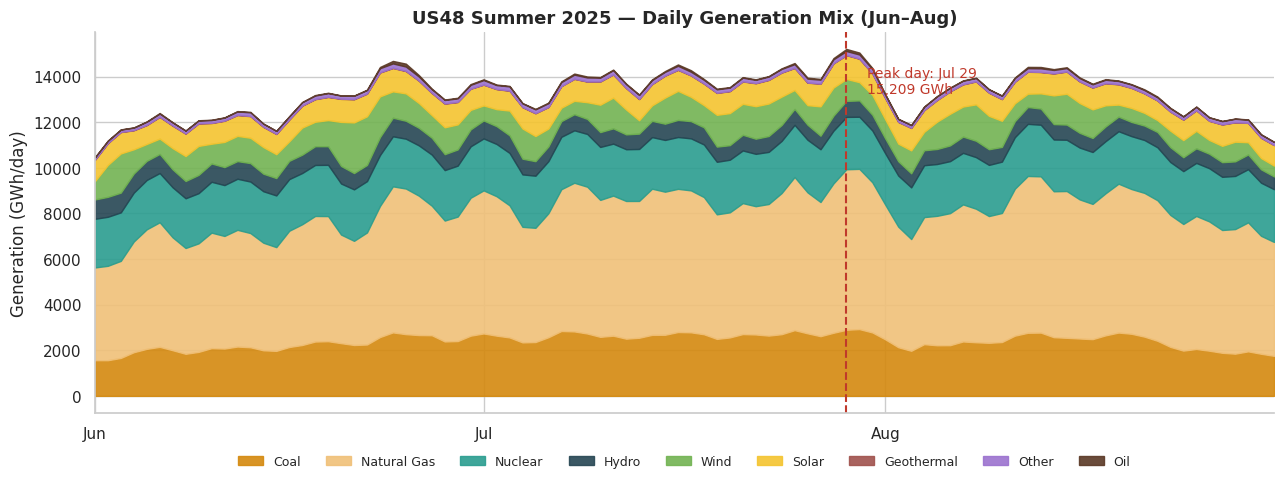


Summer peak day: Tuesday July 29
  Total: 15,209 GWh
  Coal          :  2898.0 GWh ( 19.1%)
  Natural Gas   :  7037.1 GWh ( 46.3%)
  Nuclear       :  2295.6 GWh ( 15.1%)
  Hydro         :   702.1 GWh (  4.6%)
  Wind          :   961.9 GWh (  6.3%)
  Solar         :  1042.1 GWh (  6.9%)
  Geothermal    :    10.9 GWh (  0.1%)
  Other         :   170.1 GWh (  1.1%)
  Oil           :    91.5 GWh (  0.6%)


In [5]:
summer = daily.loc['2025-06-01':'2025-08-31']
peak_day = summer[STACK_ORDER].sum(axis=1).idxmax()

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(summer))
for col in STACK_ORDER:
    vals = summer[col].values / 1e3
    ax.fill_between(summer.index, bottom, bottom + vals,
                    color=FUEL_COLORS.get(col, '#888'),
                    label=FUEL_LABELS.get(col, col), alpha=0.9)
    bottom += vals

ax.axvline(peak_day, color='#C0392B', linestyle='--', linewidth=1.5)
ax.annotate(
    f'Peak day: {peak_day.strftime("%b %d")}\n{summer.loc[peak_day, STACK_ORDER].sum()/1e3:,.0f} GWh',
    xy=(peak_day, bottom.max() * 0.95),
    xytext=(15, 0), textcoords='offset points',
    fontsize=10, color='#C0392B', va='top',
)

ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Summer 2025 — Daily Generation Mix (Jun–Aug)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=9, frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(summer.index.min(), summer.index.max())
sns.despine()
plt.tight_layout()
plt.show()

peak_mix = summer.loc[peak_day, STACK_ORDER]
peak_total = peak_mix.sum()
print(f'\nSummer peak day: {peak_day.strftime("%A %B %d")}')
print(f'  Total: {peak_total/1e3:,.0f} GWh')
for fuel in STACK_ORDER:
    pct = peak_mix[fuel] / peak_total * 100
    print(f'  {FUEL_LABELS.get(fuel, fuel):14s}: {peak_mix[fuel]/1e3:7.1f} GWh ({pct:5.1f}%)')

## 5. Winter heating stress

Unlike Texas (electric heat share is lower), US-wide winter peaks reflect heavy natural-gas heating load in the Northeast + Midwest. Cold snaps push coal and gas up while wind can swing either way. Mark the highest-gas day of the winter window.

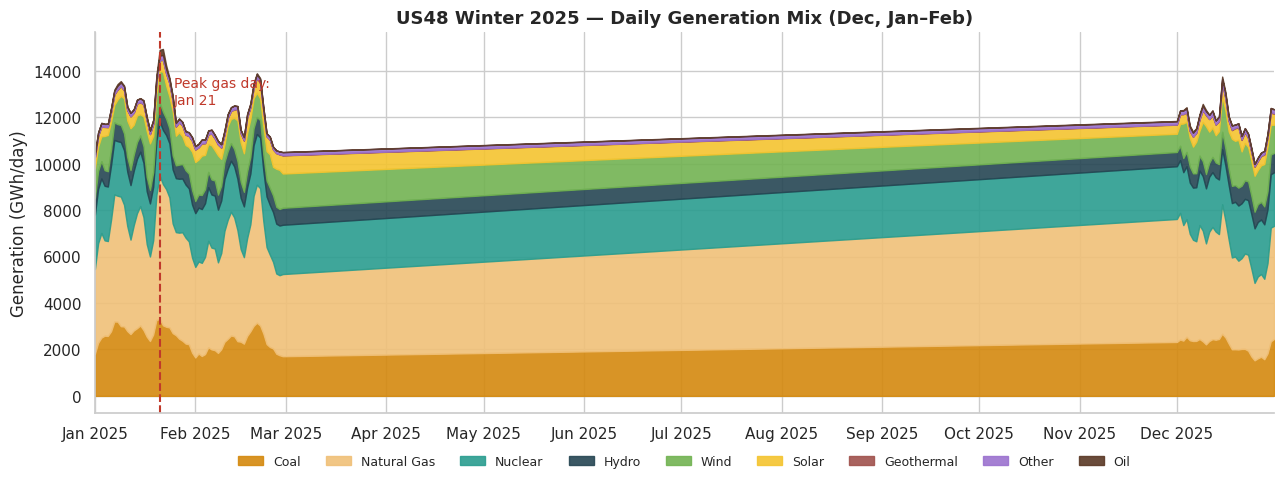


Winter peak gas day: Tuesday January 21
  Gas:       6,173.9 GWh
  Coal:      3,317.4 GWh
  Wind:      1,381.0 GWh
  Nuclear:   2,331.9 GWh
  Intensity: 0.396 tCO2/MWh


In [6]:
winter_mask = daily['month'].isin([12, 1, 2])
winter = daily.loc[winter_mask].sort_index()
winter_peak_gas = winter['NG'].idxmax()

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(winter))
for col in STACK_ORDER:
    vals = winter[col].values / 1e3
    ax.fill_between(winter.index, bottom, bottom + vals,
                    color=FUEL_COLORS.get(col, '#888'),
                    label=FUEL_LABELS.get(col, col), alpha=0.9)
    bottom += vals

ax.axvline(winter_peak_gas, color='#C0392B', linestyle='--', linewidth=1.5)
ax.annotate(
    f'Peak gas day:\n{winter_peak_gas.strftime("%b %d")}',
    xy=(winter_peak_gas, bottom.max() * 0.92),
    xytext=(10, 0), textcoords='offset points',
    fontsize=10, color='#C0392B', va='top',
)

ax.set_ylabel('Generation (GWh/day)')
ax.set_title('US48 Winter 2025 — Daily Generation Mix (Dec, Jan–Feb)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=9, frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(winter.index.min(), winter.index.max())
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nWinter peak gas day: {winter_peak_gas.strftime("%A %B %d")}')
mix = winter.loc[winter_peak_gas]
print(f'  Gas:       {mix["NG"]/1e3:,.1f} GWh')
print(f'  Coal:      {mix["COL"]/1e3:,.1f} GWh')
print(f'  Wind:      {mix["WND"]/1e3:,.1f} GWh')
print(f'  Nuclear:   {mix["NUC"]/1e3:,.1f} GWh')
if 'intensity' in mix.index:
    print(f'  Intensity: {mix["intensity"]:.3f} tCO2/MWh')

## 6. Solar's diurnal shape — month by month

The hourly data from N01 lets us look at the *shape* of solar within a day and watch that shape shift with the seasons. In June the solar bump is wide and fat; in December it's a narrow spike. This is the raw material for the national duck-curve story (NB 06 in Texas, future NB for US).

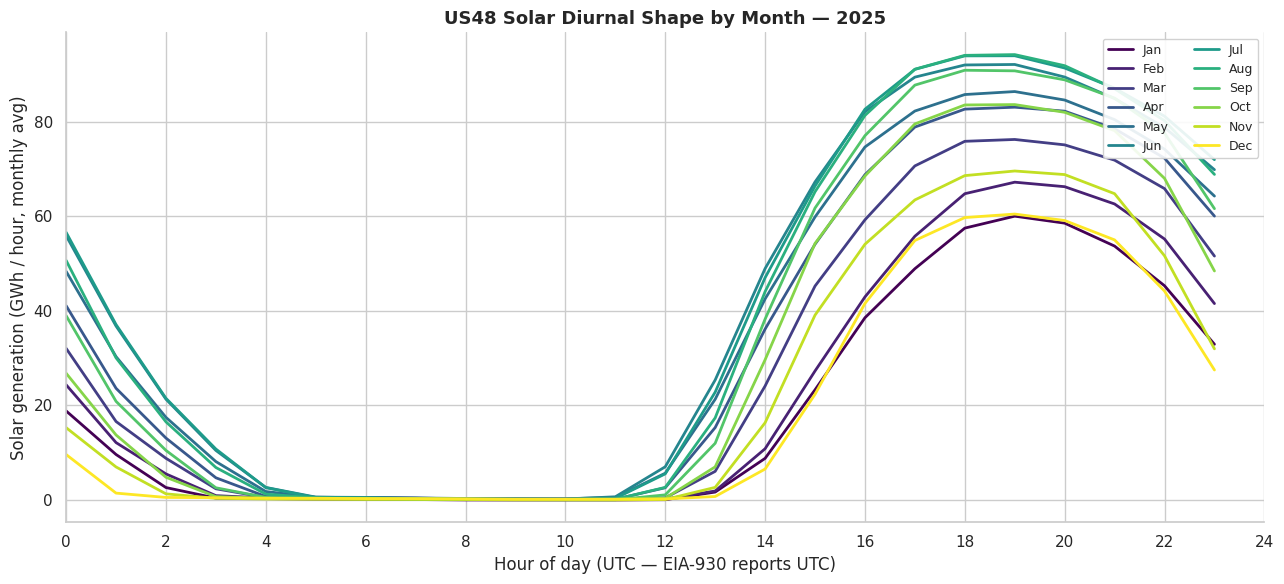

Solar peak hour (UTC) and GWh by month:
  Jan: hour 19 UTC →  60.0 GWh/h
  Feb: hour 19 UTC →  67.2 GWh/h
  Mar: hour 19 UTC →  76.2 GWh/h
  Apr: hour 19 UTC →  83.1 GWh/h
  May: hour 19 UTC →  86.4 GWh/h
  Jun: hour 19 UTC →  92.1 GWh/h
  Jul: hour 19 UTC →  94.0 GWh/h
  Aug: hour 19 UTC →  94.2 GWh/h
  Sep: hour 18 UTC →  90.9 GWh/h
  Oct: hour 19 UTC →  83.6 GWh/h
  Nov: hour 19 UTC →  69.6 GWh/h
  Dec: hour 19 UTC →  60.5 GWh/h


In [7]:
solar_hourly = hourly['SUN'].copy() / 1e3   # MWh/hour → GWh/hour

pivot = solar_hourly.groupby([hourly['month'], hourly['hour']]).mean().unstack('hour')
pivot = pivot.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.get_cmap('viridis')
for i, month in enumerate(range(1, 13)):
    vals = pivot.loc[month]
    ax.plot(vals.index, vals.values,
            color=cmap(i / 11), linewidth=2,
            label=MONTH_NAMES[month - 1])

ax.set_xlabel('Hour of day (UTC — EIA-930 reports UTC)')
ax.set_ylabel('Solar generation (GWh / hour, monthly avg)')
ax.set_title('US48 Solar Diurnal Shape by Month — 2025',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print('Solar peak hour (UTC) and GWh by month:')
for month in range(1, 13):
    row = pivot.loc[month]
    peak_h = row.idxmax()
    peak_v = row.max()
    print(f'  {MONTH_NAMES[month-1]}: hour {peak_h:2d} UTC → {peak_v:5.1f} GWh/h')

## 7. Monthly emissions intensity

Which months emit the least CO₂ per MWh delivered?

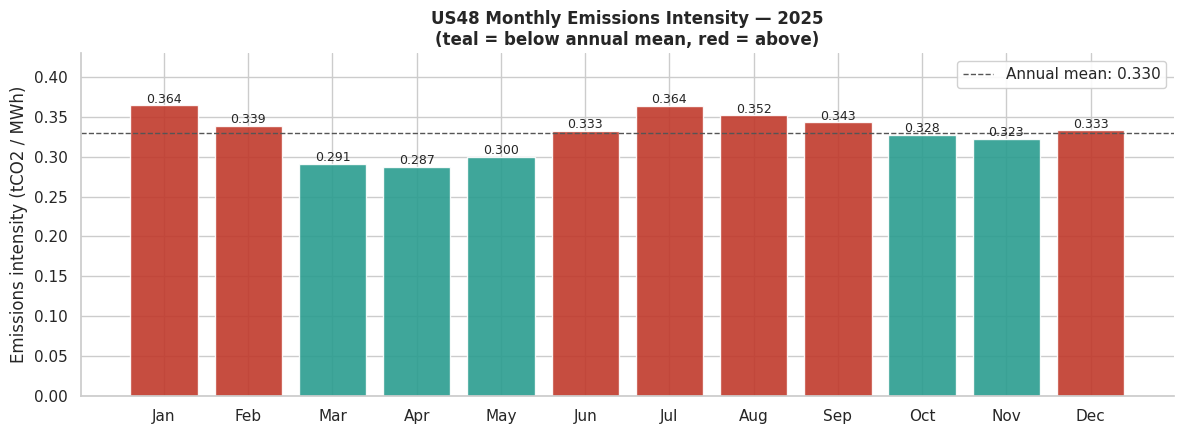


Monthly intensity ranking (cleanest first):
   1. Apr: 0.287 tCO2/MWh
   2. Mar: 0.291 tCO2/MWh
   3. May: 0.300 tCO2/MWh
   4. Nov: 0.323 tCO2/MWh
   5. Oct: 0.328 tCO2/MWh
   6. Jun: 0.333 tCO2/MWh
   7. Dec: 0.333 tCO2/MWh
   8. Feb: 0.339 tCO2/MWh
   9. Sep: 0.343 tCO2/MWh
  10. Aug: 0.352 tCO2/MWh
  11. Jul: 0.364 tCO2/MWh
  12. Jan: 0.364 tCO2/MWh


In [8]:
monthly_ei = daily.groupby('month')['intensity'].mean()
annual_mean = daily['intensity'].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#C0392B' if v > annual_mean else '#2A9D8F' for v in monthly_ei.values]
bars = ax.bar(MONTH_NAMES, monthly_ei.values, color=colors, alpha=0.9)
for bar, val in zip(bars, monthly_ei.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', fontsize=9)

ax.axhline(annual_mean, color='#555', linestyle='--', linewidth=1,
           label=f'Annual mean: {annual_mean:.3f}')
ax.set_ylabel('Emissions intensity (tCO2 / MWh)')
ax.set_title('US48 Monthly Emissions Intensity — 2025\n(teal = below annual mean, red = above)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, monthly_ei.max() * 1.18)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print('\nMonthly intensity ranking (cleanest first):')
for i, (m, v) in enumerate(monthly_ei.sort_values().items(), 1):
    print(f'  {i:2d}. {MONTH_NAMES[m-1]}: {v:.3f} tCO2/MWh')

## Key findings

1. **The US grid has two peaks, not one.** Winter heating (Jan-Feb) and summer AC (Jul-Aug) both push total generation high — unlike Texas where summer dominates or India where summer is the main heat peak.
2. **Spring is the renewables moment.** March–May has the highest wind generation and rising solar — the combined clean share is at its seasonal best before summer demand ramps up.
3. **Summer peak is gas-heavy.** When AC load spikes, natural gas carries most of the incremental load, with solar helping midday. Coal contributes too but solar ~doubles from winter to summer.
4. **Winter dirtiest ≠ summer dirtiest.** The intensity chart tells a nuanced story — the cleanest month is likely April/May when wind is peaking and AC isn't firing yet.
5. **Solar's shape widens in summer and narrows in winter** — a 3-hour December window versus a 7-hour June window. The duck curve shape is fundamentally seasonal.
6. **Compare:**
   - India 2024 cleanest month (August, monsoon): ~0.62 tCO2/MWh
   - US cleanest month (TBD, likely April): ~0.31 tCO2/MWh
   - Texas cleanest month (likely March-May): ~0.25 tCO2/MWh

→ Next: Notebook 05 — Renewable Share